<a href="https://colab.research.google.com/github/25me01030-Dhruv/git-demo/blob/main/CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

In [ ]:
import torchvision
import torchvision.transforms as transforms

# Loading and Preprocessing the data CIFAR 10

In [ ]:
# Apply normalization into pixels with mean 0.5 and SD 0.5.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),  # Apply normalization into pixels with mean 0.5 and SD 0.5.
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop([32,32])
])

In [ ]:
# Download and load the training set

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:04<00:00, 40.4MB/s]


In [ ]:
# Download and load the test set
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [ ]:
print(f"{len(testset)} : Test images")
print(f"{len(trainset)} : Train images")

10000 : Test images
50000 : Train images


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as Fun

In [ ]:
torch.manual_seed(42)

In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
trainloader = DataLoader(trainset, batch_size=200, shuffle=True, num_workers=5)   # Building batches for the training set out of 50000 images
testloader = DataLoader(testset, batch_size=200, shuffle = False, num_workers=5)   # Building batches for the training set out of 10000 images

classes = ('plane', 'car', 'bird', 'cat','deer', 'dog', 'frog', 'horse', 'ship', 'truck')   # Got the names from the internet

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
for images,labels in trainloader :
 print(f'Images  : ', images.shape)
 print(f'Labels  : ', labels.shape)
 break

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Images  :  torch.Size([200, 3, 32, 32])
Labels  :  torch.Size([200])


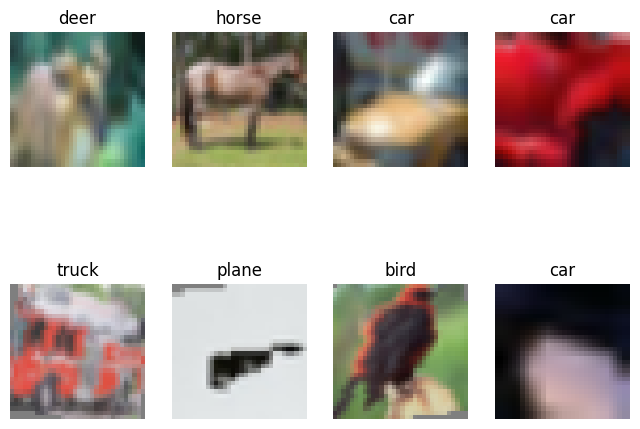

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

fig, axes = plt.subplots(2,4, figsize=(8,6))
axes = axes.ravel()

for i in range (len(axes)) :    # 8
  image_index = random.randint(0,len(trainset)-1)
  image, label = trainset[image_index]
  axes[i].imshow(image.permute(1, 2, 0).numpy() / 2 + 0.5)  # Convert image into numpy array of height : 1, width : 2, channel : 0 and then denormalize
  axes[i].set_title(classes[label])
  axes[i].axis('off')

plt.show()

In [ ]:
len(axes)

8

# Residual block

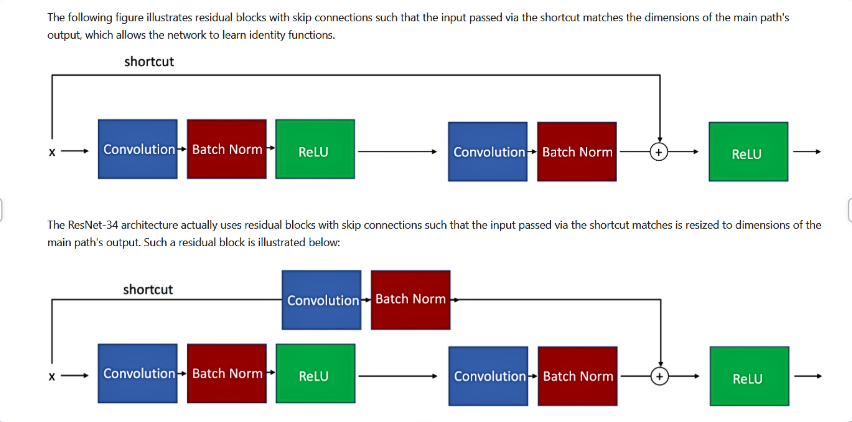

In [ ]:
class ResidualBlock(nn.Module) :
  def __init__(self,in_channels, out_channels, stride = 1, downsample = None) :
     super(ResidualBlock,self).__init__()

     # First convolution layer
     self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size = 3, stride = stride, padding = 1, bias = False)
     self.bn1 = nn.BatchNorm2d(out_channels)
     self.relu = nn.ReLU()

     # 2nd convolution layer
     self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding = 1, stride = 1, bias = False)
     self.bn2 = nn.BatchNorm2d(out_channels)

     self.shortcut = nn.Sequential()  # dim of x and result are same

     if stride != 1 or in_channels != out_channels:   # dim of x and result are not same then apply convolution and batch_normalization to make them equal
          self.shortcut = nn.Sequential(
                  nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                  nn.BatchNorm2d(out_channels)
                  )

  def forward(self,x) :

       # First layer
       result = self.conv1(x)
       result = self.bn1(result)
       result = self.relu(result)

       # Second layer
       result = self.conv2(result)
       result = self.bn2(result)

       result += self.shortcut(x)
       result = self.relu(result)

       return result

# ResNet architecture

In [ ]:
class ResNet18 (nn.Module) :

  def __init__(self, n_class = 10) :
      super(ResNet18, self).__init__()

      self.in_channels = 64   # No of channels

      # Initial convolutional layer
      self.conv1 = nn.Conv2d(3, 64, kernel_size=5, stride=1, padding=1, bias=False)
      self.bn1 = nn.BatchNorm2d(64)
      self.relu = nn.ReLU(inplace=True)

      # 4 layers for residual block
      self.layer1 = self._make_layer(ResidualBlock, 64,  2,  stride = 1)
      self.layer2 = self._make_layer(ResidualBlock, 128, 2,  stride = 2)
      self.layer3 = self._make_layer(ResidualBlock, 256, 2,  stride = 2)
      self.layer4 = self._make_layer(ResidualBlock, 512, 2,  stride = 2)

      # Average pooling layer
      self.avgpool = nn.AdaptiveAvgPool2d((1,1))

      # ANN layer
      self.fully_connected = nn.Linear(512, n_class)

  def _make_layer(self, block, out_channels, num_blocks, stride):
    strides = [stride] + [1]*(num_blocks-1)
    layers = []
    for s in strides:
        layers.append(block(self.in_channels, out_channels, s))
        self.in_channels = out_channels
    return nn.Sequential(*layers)

  def forward(self, X) :
    result = self.conv1(X)
    result = self.bn1(result)
    result = self.relu(result)

    result = self.layer1(result)
    result = self.layer2(result)
    result = self.layer3(result)
    result = self.layer4(result)

    result = self.avgpool(result)
    result = result.view(result.size(0), -1)
    result = self.fully_connected(result)

    return result

model = ResNet18().to(device)
print(model)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1

# Loss function and Optimizer

In [ ]:
lr = 0.1
epochs = 20
lss_fn = nn.CrossEntropyLoss()

model.to(device)

optimizer = optim.SGD(model.parameters(), lr=lr, momentum = 0.7, weight_decay=1e-4)

# Training loop

> Calculating loss over each epoch



In [ ]:
for epoch in range(epochs) :
   model.train() # model in train mode
   y_loss_total = 0

   for batch_images,batch_labels in trainloader :

         batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)

         output = model(batch_images)

         loss = lss_fn(output,batch_labels)

         optimizer.zero_grad()
         loss.backward()

         optimizer.step()

         y_loss_total = y_loss_total + loss.item()

   avg_loss = y_loss_total/len(trainloader)
   print(f'Loss in epoch [{epoch+1}/20] : {avg_loss}')

# Calculating accuracy for training and testing imageset

In [ ]:
model.eval()

In [ ]:
# evaluation on train data

total = 0
correct = 0

with torch.no_grad() :
  for epoch in range(epochs) :

   for batch_images, batch_labels in trainloader:
    batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)

    output = model(batch_images)

    _, predicted = torch.max(output,1)
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()

   train_accuracy = correct/total
   print(f'epoch : [{epoch}/20]; train_accuracy : {train_accuracy}')

In [ ]:
# evaluation on test data

total = 0
correct = 0

with torch.no_grad() :
  for epoch in range(epochs) :

   for batch_images, batch_labels in testloader:
    batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)

    output = model(batch_images)

    _, predicted = torch.max(output,1)
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()

   test_accuracy = correct/total
   print(f'epoch : [{epoch}/20]; test_accuracy : {test_accuracy}')

# Plotting Training Loss alongwith training and test Accuracy

In [ ]:
plt.figure(figsize=(12,10))
plt.subplot(1,2,1)
plt.plot(epochs, train_loss, label = 'Train loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Epochs vs Loss')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(12,10))
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracy, label = 'Train accuracy')
plt.plot(epochs, test_accuracy, label = 'Test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy(%)')
plt.title('Epochs vs Accuracy')
plt.legend()
plt.show()

In [ ]:
       #  model.eval()
         num_epochs = 20
         train_losses, train_acc_list, test_acc_list = [], [], []

          for epoch in range(num_epochs):
              model.train()
              running_loss = 0.0
              correct, total = 0, 0
              for inputs, labels in trainloader:
                  inputs, labels = inputs.to(device), labels.to(device)
                  optimizer.zero_grad()
                  outputs = model(inputs)
                  loss = lss_fn(outputs, labels)
                  loss.backward()
                  optimizer.step()

                  running_loss += loss.item() * inputs.size(0)
                  _, predicted = outputs.max(1)
                  total += labels.size(0)
                  correct += predicted.eq(labels).sum().item()

              train_loss = running_loss / len(trainloader.dataset)
              train_acc = 100. * correct / total
              train_losses.append(train_loss)
              train_acc_list.append(train_acc)

              model.eval()
              correct, total = 0, 0
              with torch.no_grad():
                  for inputs, labels in testloader:
                      inputs, labels = inputs.to(device), labels.to(device)
                      outputs = model(inputs)
                      _, predicted = outputs.max(1)
                      total += labels.size(0)
                      correct += predicted.eq(labels).sum().item()
              test_acc = 100. * correct / total
              test_acc_list.append(test_acc)

              print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%')